In [2]:
import sys
import os
sys.path.append("../../utils")
sys.path.append("../../dataloader")
from plot_utils import plot_spatial
from sklearn.metrics import r2_score
import numpy as np

In [3]:
import numpy as np
def get_min_max_coords(mask, pad):
    min_x = np.min(np.where(mask)[0])
    max_x = np.max(np.where(mask)[0])
    min_y = np.min(np.where(mask)[1])
    max_y = np.max(np.where(mask)[1])
    # wid_x = math.ceil((max_x - min_x)/2)*2
    # wid_y = math.floor((max_y - min_y)/2)*2
    # return int(min_x-pad), int(min_x+wid_x+pad), \
    #     int(min_y-pad), int(min_y+wid_y+pad)
    return min_x-pad, max_x+pad, min_y-pad, max_y+pad

In [8]:
mean = np.load("../../consts/twp_region_means.npz")["CAPE"]
std = np.load("../../consts/twp_region_stds.npz")["CAPE"]
mask = np.load("../../consts/twp_region.npy")
min_x, max_x, min_y, max_y = get_min_max_coords(mask, 0)
lon = np.linspace(0,357.5,144)
lat = np.linspace(-90,90,96)
levs = np.array([
    3.64346569,   7.59481965,  14.35663225,  24.61222,     38.26829977,
      54.59547974,  72.01245055,  87.82123029, 103.31712663, 121.54724076,
       142.99403876, 168.22507977, 197.9080867,  232.82861896, 273.91081676,
        322.24190235, 379.10090387, 445.9925741,  524.68717471, 609.77869481,
         691.38943031, 763.40448111, 820.85836865, 859.53476653, 887.02024892,
          912.64454694, 936.19839847, 957.48547954, 976.32540739, 992.55609512]).astype(int)

In [17]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.ticker import FuncFormatter


363.42953186035163 25.165249633789063


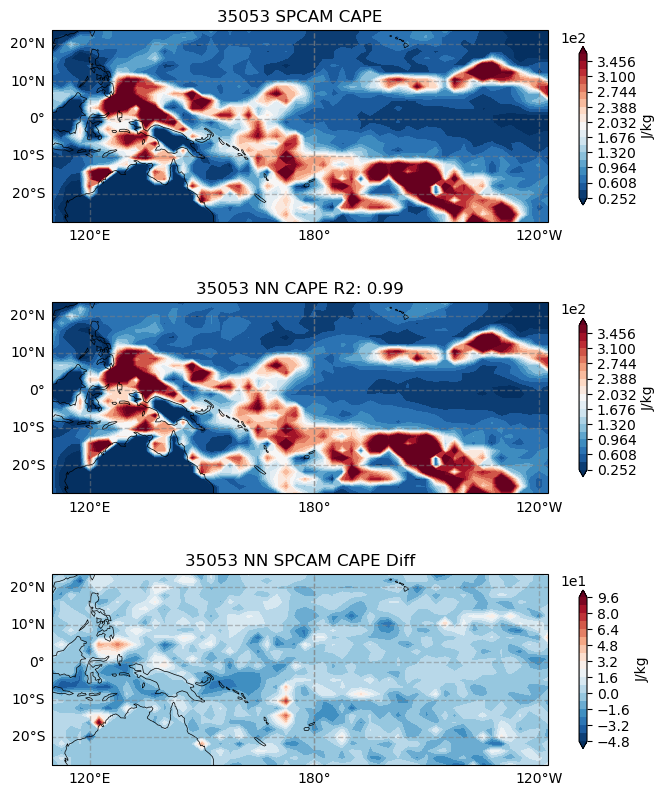

363.58912048339846 22.866027069091796


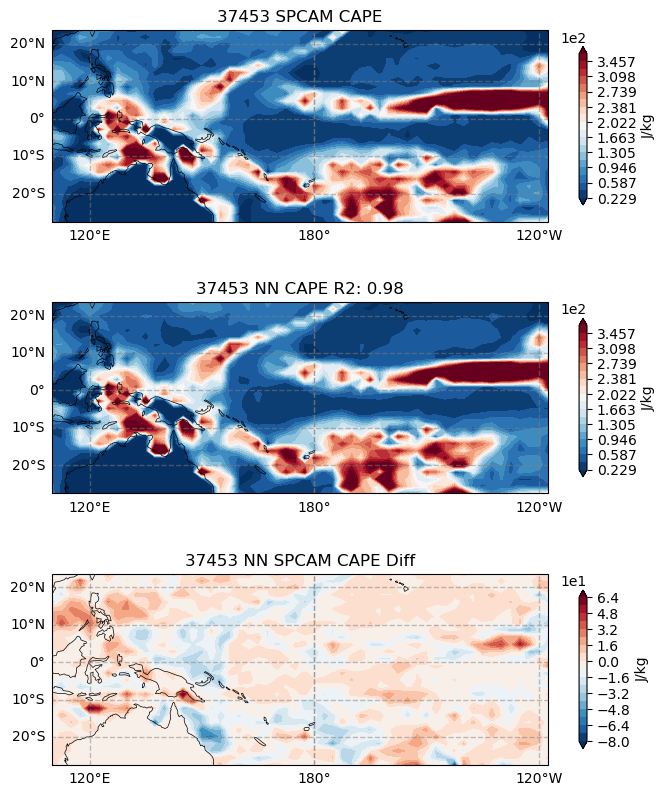

350.12602539062516 24.28278694152832


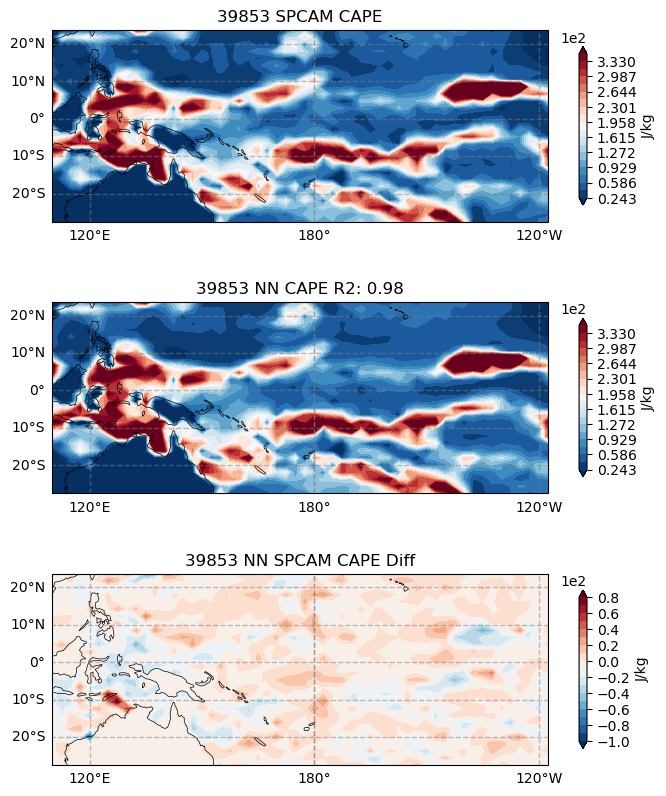

344.24555206298834 23.266233062744142


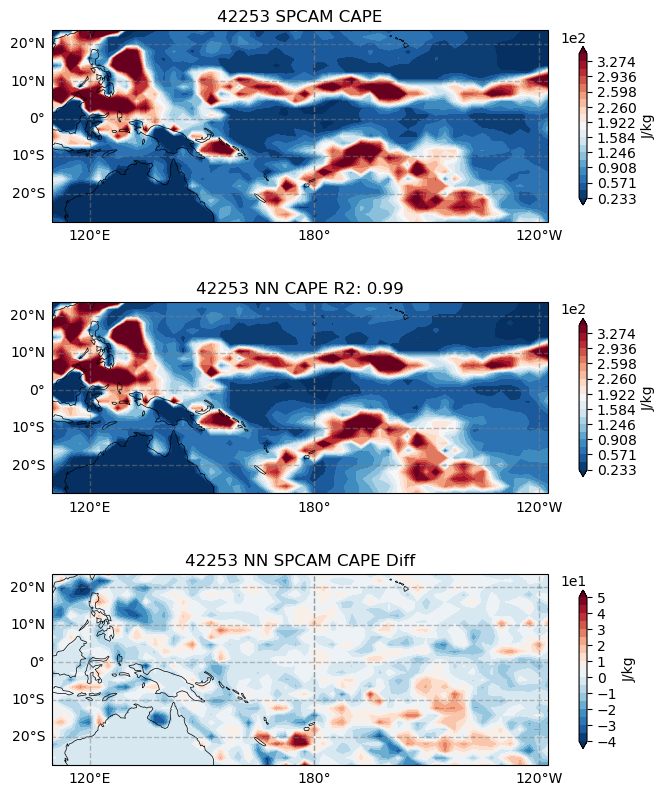

411.268524169922 20.653512573242185


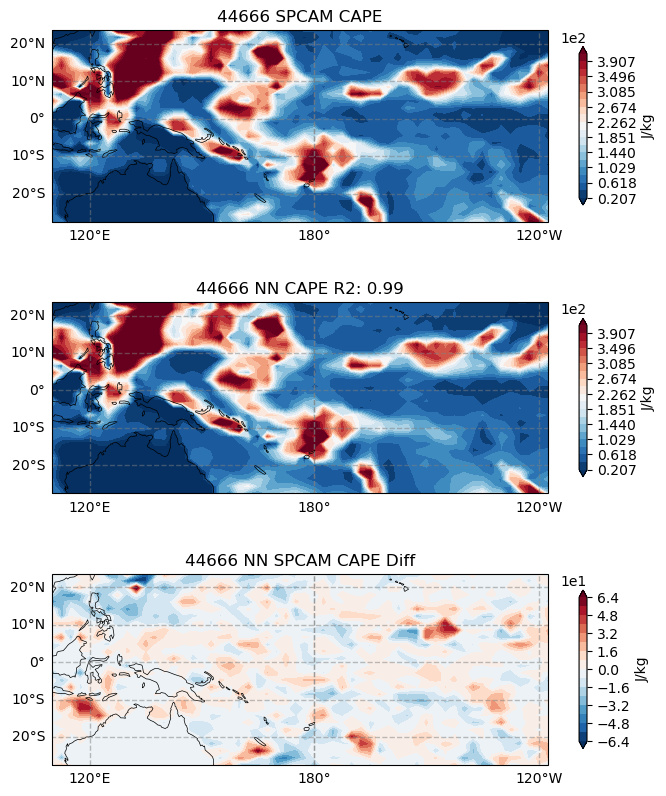

332.1548294067384 18.810776901245116


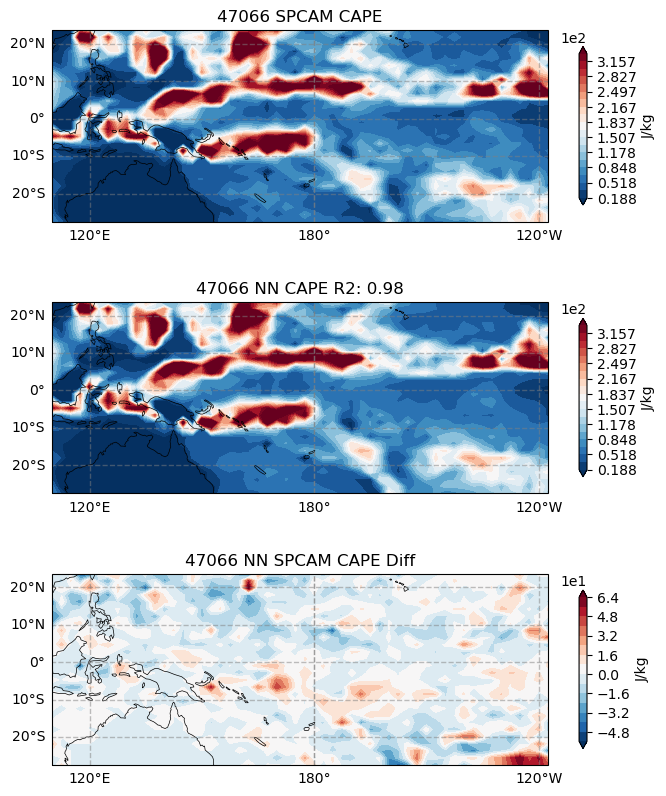

414.8188171386719 17.473151397705077


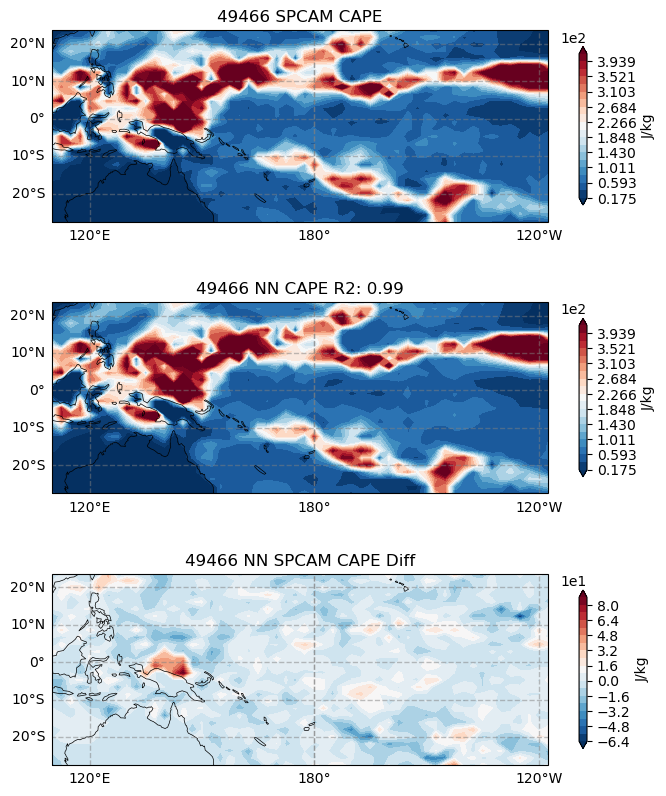

414.9257369995118 19.23352928161621


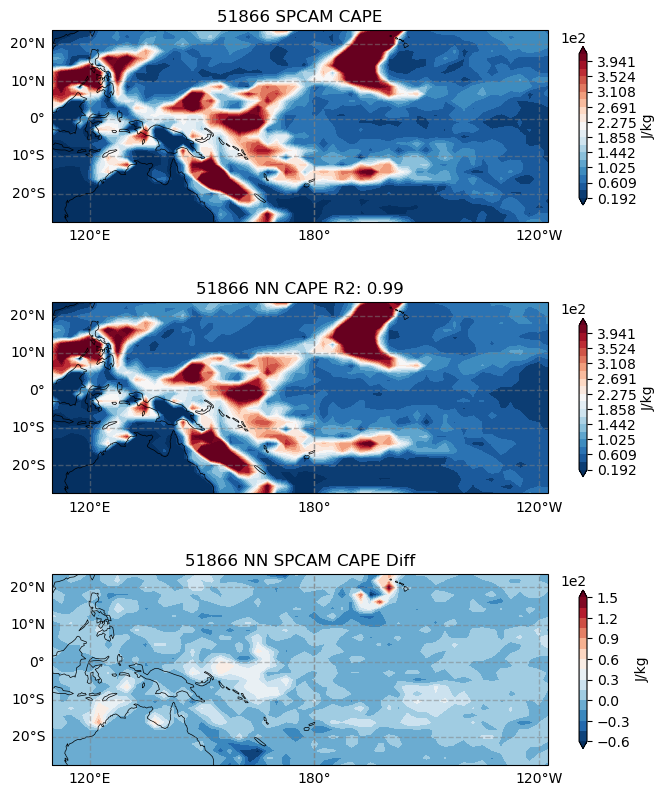

463.67592010498055 32.462148666381836


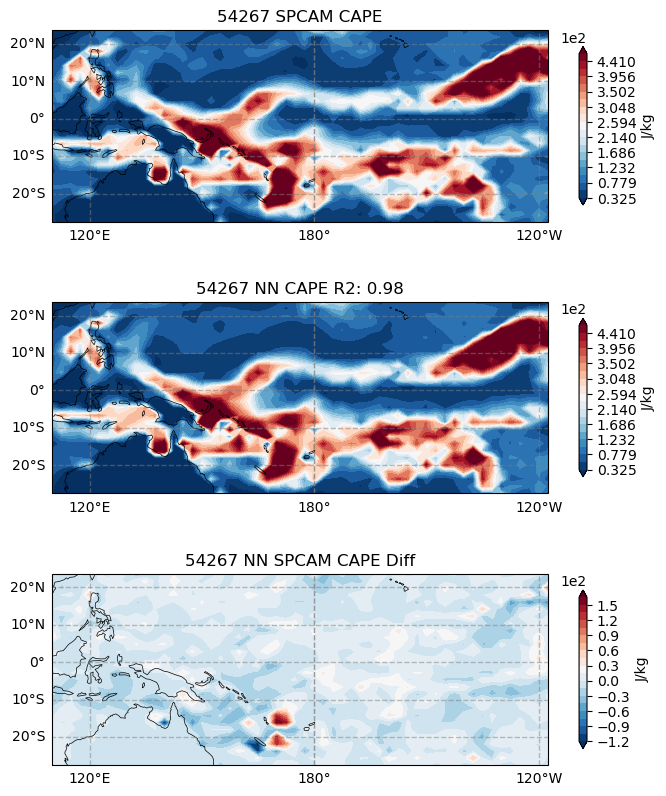

In [27]:
samples = ["35053", "37453", "39853", "42253", "44666", "47066", "49466", "51866", "54267"]
for sample in samples:
    data = np.load(f"offline_test_{sample}.npz")
    spcam = data["gt"]
    pred = data["pred"]
    spcam = (spcam*std + mean).squeeze()
    pred = (pred*std + mean).squeeze()
    one_decimal_formatter = FuncFormatter(lambda x, _: f'{x:.1e}')
    gt = np.zeros((mask.shape))
    gt[mask.astype(bool)] = spcam
    # pred_resmlp = np.zeros((mask.shape))
    # pred_resmlp[mask.astype(bool)] = avg_pred_resmlp2[:,i]
    fig, ax = plt.subplots(3,1, figsize=(8,10), subplot_kw={'projection':ccrs.PlateCarree(central_longitude=180)})
    cbar_label = "J/kg"
    ax[0].set_title(f"{sample} SPCAM CAPE")
    vmax = np.quantile(spcam, 0.95)+1e-16
    vmin = np.quantile(spcam, 0.05)-1e-16
    print(vmax, vmin)
    plot_spatial(lon[min_y:max_y], lat[min_x:max_x], gt[min_x:max_x,min_y:max_y],ax=ax[0], cbar_label=cbar_label, vmin=vmin, vmax=vmax, cmap="RdBu_r", cbar_formatter=one_decimal_formatter)
    nn = np.zeros((mask.shape))
    nn[mask.astype(bool)] = pred
    ax[1].set_title(f"{sample} NN CAPE R2: {r2_score(data['gt'][:,0], data['pred'][:,0]):.2f}")
    plot_spatial(lon[min_y:max_y], lat[min_x:max_x], nn[min_x:max_x,min_y:max_y],ax=ax[1], cbar_label=cbar_label, vmin=vmin, vmax=vmax, cmap="RdBu_r", cbar_formatter=one_decimal_formatter)
    nn_diff = np.zeros((mask.shape))
    nn_diff[mask.astype(bool)] = (spcam-pred)
    ax[2].set_title(f"{sample} NN SPCAM CAPE Diff")
    plot_spatial(lon[min_y:max_y], lat[min_x:max_x], nn_diff[min_x:max_x,min_y:max_y],ax=ax[2], cbar_label=cbar_label, cmap="RdBu_r", cbar_formatter=one_decimal_formatter)
    plt.show()